In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict
from itertools import product
import gurobipy as gp
from gurobipy import GRB
import itertools
from datetime import datetime, timedelta  
import glob

## 데이터 불러오기
### 데이터 전처리

In [2]:
# # 헤더명 매핑
# mapping = {
#     'Periodo': 'Time Period',
#     'Fecha': 'Date',
#     'Precio Compra/Venta': 'Price',
#     'Potencia Compra/Venta': 'Amount',
#     'Tipo Oferta': 'GC'
# }

# # 마지막 점(.)만 남기기
# pattern = r'\.(?=[^.]*\.)'

# # 데이터 저장된 폴더
# data_dir = "rdcdata"

# # 날짜 범위
# start_date = datetime(2025, 4, 20)
# end_date   = datetime(2025, 7, 28)
# date_list  = pd.date_range(start_date, end_date, freq="D")

# for date in date_list:
#     date_str = date.strftime("%Y%m%d")
#     in_file  = os.path.join(data_dir, f"curva_pbc_{date_str}.1")
#     mid_file = os.path.join(data_dir, f"curve_{date_str}.csv")
#     out_file = os.path.join(data_dir, f"filteredcurve_{date_str}.csv")

#     if os.path.isfile(in_file):
#         # 1) 원본 읽기
#         df = pd.read_csv(in_file, sep=';', encoding='latin-1', skiprows=2)
#         df = df.rename(columns=mapping)
#         df.to_csv(mid_file, index=False, encoding='utf-8-sig')
#         print(f"✔ Converted: {in_file} → {mid_file}")

#         # 2) 숫자 문자열 정리
#         df = pd.read_csv(mid_file, sep=',', encoding='utf-8-sig')
#         df['Price']  = (df['Price'].astype(str)
#                                   .str.replace(',', '.', regex=False)
#                                   .apply(lambda s: re.sub(pattern, '', s)))
#         df['Amount'] = (df['Amount'].astype(str)
#                                   .str.replace(',', '.', regex=False)
#                                   .apply(lambda s: re.sub(pattern, '', s)))
#         df['Price']  = pd.to_numeric(df['Price'], errors='coerce')
#         df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

#         # 3) 최종 저장
#         df.to_csv(out_file, sep=',', index=False, encoding='utf-8-sig')
#         print(f"✔ Cleaned: {mid_file} → {out_file}")

#     else:
#         print(f"⚠ File not found: {in_file}")


### 시나리오 생성

In [12]:
# --- 2) 불러오기 ---
df = pd.read_csv("rdc_scenarios0925.csv", encoding="utf-8-sig")  # 파일명 일반화

# 날짜 범위 필터 (2025-04-20 ~ 2025-07-28)
df["scenario"] = df["scenario"].astype(str)
df = df[(df["scenario"] >= "20250420") & (df["scenario"] <= "20250728")]

# 날짜별 scenario 리스트
date_range = sorted(df["scenario"].unique().tolist())   # ["20250420", ..., "20250728"]
S = list(range(len(date_range)))                        # 시나리오 index
T = list(range(1, 25))                                  # 시간
I = [0]
J = [1,2,3,4]
Δt = 0.25
rho = {s: 1/len(S) for s in S}                          # 균등 확률

# 시나리오 문자열(날짜) → 숫자 index 매핑
s_map = {date: idx for idx, date in enumerate(date_range)}

# --- 3) 최종 dict 구성 ---
qini_scen_final      = {}
qmax_scen_final      = {}
lambda_da_scen_final = {}
valid_blocks         = {t: [] for t in T}

for (s, t), sub in df.groupby(["scenario", "t"]):
    sub_sorted = sub.sort_values("qini").reset_index(drop=True)
    for b, r in sub_sorted.iterrows():
        s_idx = s_map[s]   # 예: "20250420" → 0, "20250421" → 1 ...
        qini_scen_final[(t,b,s_idx)]      = float(r["qini"])
        qmax_scen_final[(t,b,s_idx)]      = float(r["qmax"])
        lambda_da_scen_final[(t,b,s_idx)] = float(r["lam_da"])
        if r["qmax"] > 0:
            valid_blocks[t].append(b)

# 중복 제거
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

print(f"총 시나리오 개수: {len(S)} (기간: {date_range[0]} ~ {date_range[-1]})")
print("예시 qini_scen_final keys:", list(qini_scen_final.keys())[:10])
print("예시 valid_blocks[1]:", valid_blocks[1])

총 시나리오 개수: 100 (기간: 20250420 ~ 20250728)
예시 qini_scen_final keys: [(1, 0, 0), (1, 1, 0), (1, 2, 0), (1, 3, 0), (1, 4, 0), (1, 5, 0), (1, 6, 0), (1, 7, 0), (1, 8, 0), (1, 9, 0)]
예시 valid_blocks[1]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 18

In [78]:
# ---------------------------
# 1) 파일 로드
# ---------------------------
# 발전량 (결측 보정된 버전)
df_pwf = pd.read_csv("co2freegeneration_filled.csv", sep=",")
df_pwf["datetime"] = pd.to_datetime(df_pwf["datetime"])
df_pwf["date"] = df_pwf["datetime"].dt.date
df_pwf["hour"] = df_pwf["datetime"].dt.hour

# 실시간 가격 (marginalpibc에서)
rt_files = sorted(glob.glob("rtdata/marginalpibc_2025*.1"))

# ---------------------------
# 1) 기본 설정
# ---------------------------
start_date = pd.to_datetime("2025-04-20")
end_date   = pd.to_datetime("2025-07-28")
dates = pd.date_range(start=start_date, end=end_date, freq="D")

W = list(range(len(dates)))   # 0..99
rho_w = {w: 1/len(W) for w in W}

# ---------------------------
# 2) 빅 딕셔너리 초기화
# ---------------------------
qini_big, qmax_big, lambda_da_big = {}, {}, {}
pwf_big, rt_big = {}, {}
valid_blocks_by_w = defaultdict(list)

# rtdata 파일 목록
# ---------------------------
# 3) 날짜별 시나리오 생성
# ---------------------------
for w, date in enumerate(dates):
    date_str = date.strftime("%Y%m%d")

    # --- RDC 매핑 (날짜 = 시나리오) ---
    for (t,b,s) in qini_scen_final.keys():
        if s != w:   # 🔹 시나리오 인덱스로 매칭
            continue
        qini_big[(t,b,w)]      = qini_scen_final[(t,b,s)]
        qmax_big[(t,b,w)]      = qmax_scen_final[(t,b,s)]
        lambda_da_big[(t,b,w)] = lambda_da_scen_final[(t,b,s)]
        if qmax_big[(t,b,w)] > 0:
            valid_blocks_by_w[(t,w)].append(b)

    # --- 발전량 (pwf, 시간 단위) ---
    sub_pwf = df_pwf[df_pwf["date"] == date.date()]
    for _, row in sub_pwf.iterrows():
        t = int(row["hour"]) + 1   # 0~23 → 1~24
        pwf_big[(0,t,w)] = row["value"]/20

    # --- 실시간 가격 (rt, 15분 단위 96개 → t,j로 매핑) ---
    fmatch = [f for f in rt_files if date_str in f]
    if fmatch:
        df_rt = pd.read_csv(fmatch[0], sep=";", encoding="latin-1", skiprows=1, header=None)
        df_rt = df_rt.dropna(how="all", axis=1)
        df_rt.columns = ["Year","Month","Day","Period","Price1","Price2"][:df_rt.shape[1]]

        df_rt = df_rt.dropna(subset=["Period","Price1"])
        df_rt["Period"] = df_rt["Period"].astype(int)

        # 🔹 Period가 반드시 1~96까지 있어야 함 (누락 방지)
        if set(df_rt["Period"].unique()) == set(range(1,97)):
            for _, row in df_rt.iterrows():
                period = int(row["Period"])
                t = (period-1)//4 + 1   # 1~96 → 1~24
                j = (period-1)%4 + 1    # 1~96 → 1~4
                rt_big[(t,j,w)] = float(row["Price1"])/10
        else:
            print(f"⚠ {date.date()} RT 데이터 개수 부족: {len(df_rt)}개")


    # 블록 정리
    for t in range(1,25):
        valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))

# ---------------------------
# 4) 결과 확인
# ---------------------------
print("총 시나리오 수:", len(W))        # 100
print("예시 qini_big:", list(qini_big.items())[:3])
print("예시 pwf_big:", list(pwf_big.items())[:3])
print("예시 rt_big:", list(rt_big.items())[:6])  # j=1..4 구조 확인


총 시나리오 수: 100
예시 qini_big: [((1, 0, 0), 0.0), ((1, 1, 0), 7.96), ((1, 2, 0), 19.9)]
예시 pwf_big: [((0, 1, 0), 804.725), ((0, 2, 0), 758.316666666667), ((0, 3, 0), 711.741666666667)]
예시 rt_big: [((1, 1, 0), -0.5), ((1, 2, 0), -0.521), ((1, 3, 0), -0.521), ((1, 4, 0), -0.521), ((2, 1, 0), -0.521), ((2, 2, 0), -0.521)]


In [124]:
base_date = pd.to_datetime("2025-04-25")   # 예: 하루 선택

W = list(range(100))   # 100개 시나리오
rho_w = {w: 1/len(W) for w in W}

base_date = pd.to_datetime("2025-06-01")
date_str  = base_date.strftime("%Y%m%d")

# --- 원본 데이터 ---
# 발전량
sub_pwf = df_pwf[df_pwf["date"] == base_date.date()]
pwf_base = {int(row["hour"])+1: row["value"]/20 for _,row in sub_pwf.iterrows()}

# 실시간 가격
fmatch = [f for f in rt_files if date_str in f]
df_rt = pd.read_csv(fmatch[0], sep=";", encoding="latin-1", skiprows=1, header=None)
df_rt = df_rt.dropna(how="all", axis=1)
df_rt.columns = ["Year","Month","Day","Period","Price1","Price2"][:df_rt.shape[1]]
df_rt = df_rt.dropna(subset=["Period","Price1"])
df_rt["Period"] = df_rt["Period"].astype(int)
rt_base = {}
for _, row in df_rt.iterrows():
    period = int(row["Period"])
    t = (period-1)//4 + 1
    j = (period-1)%4 + 1
    rt_base[(t,j)] = float(row["Price1"])/4

# --- 노이즈 기반 시나리오 생성 ---
pwf_big, rt_big = {}, {}
qini_big, qmax_big, lambda_da_big = {}, {}, {}
valid_blocks_by_w = defaultdict(list)

# for w in W:
#     # 발전량: ±5% 가우시안 노이즈
#     for t,v in pwf_base.items():
#         noise = np.random.normal(0, 0.05)   # 평균0, 표준편차5%
#         pwf_big[(0,t,w)] = max(0, v*(1+noise))

#     # 실시간 가격: ±2 €/MWh additive noise
#     for (t,j),v in rt_base.items():
#         noise = np.random.normal(0, 2)
#         rt_big[(t,j,w)] = max(0, v+noise)

#     # 블록 데이터 (여기도 살짝 노이즈 추가)
#     for (t,b,s) in qini_scen_final.keys():
#         if s != 0:   # 🔹 기준일만 사용
#             continue
#         qini_big[(t,b,w)]      = qini_scen_final[(t,b,s)] * (1+np.random.normal(0,0.005))
#         qmax_big[(t,b,w)]      = qmax_scen_final[(t,b,s)]
#         lambda_da_big[(t,b,w)] = lambda_da_scen_final[(t,b,s)] + np.random.normal(0,0.005)
#         if qmax_big[(t,b,w)] > 0:
#             valid_blocks_by_w[(t,w)].append(b)

#     valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))
# base_date를 scenario 인덱스로 변환
date_str  = base_date.strftime("%Y%m%d")
s_base = s_map[date_str]   # 예: "20250601" → 대응하는 인덱스

for w in W:
    # 발전량: ±5% 가우시안 노이즈
    for t,v in pwf_base.items():
        noise = np.random.normal(0, 0.05)
        pwf_big[(0,t,w)] = max(0, v*(1+noise))

    # 실시간 가격: ±2 €/MWh additive noise
    for (t,j),v in rt_base.items():
        noise = np.random.normal(0, 2)
        rt_big[(t,j,w)] = max(0, v+noise)

    # RDC (base_date = s_base) 기준
    for (t,b,s) in qini_scen_final.keys():
        if s != s_base:
            continue
        qini_big[(t,b,w)]      = qini_scen_final[(t,b,s)] * (1+np.random.normal(0,0.05))
        qmax_big[(t,b,w)]      = qmax_scen_final[(t,b,s)]
        lambda_da_big[(t,b,w)] = lambda_da_scen_final[(t,b,s)] + np.random.normal(0,0.05)
        if qmax_big[(t,b,w)] > 0:
            valid_blocks_by_w[(t,w)].append(b)

    valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))



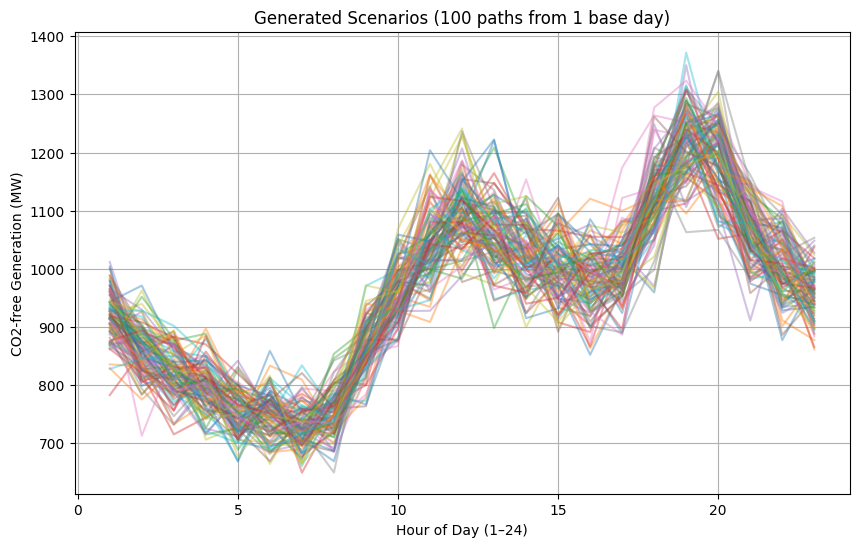

In [125]:
plt.figure(figsize=(10,6))
for w in W:   # 모든 시나리오
    vals = [pwf_big[(0,t,w)] for t in range(1,24)]
    plt.plot(range(1,24), vals, alpha=0.4)
plt.xlabel("Hour of Day (1–24)")
plt.ylabel("CO2-free Generation (MW)")
plt.title(f"Generated Scenarios ({len(W)} paths from 1 base day)")
plt.grid(True)
plt.show()

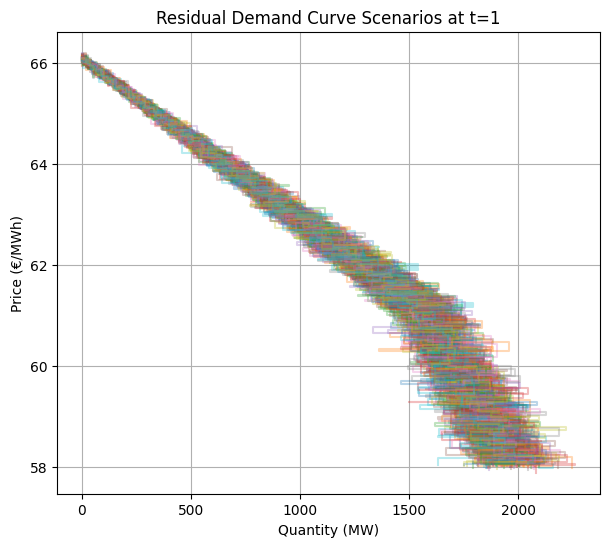

In [126]:
t = 1   # 예: 12시 기준
plt.figure(figsize=(7,6))
for w in W:
    q_vals, p_vals = [], []
    for b in valid_blocks_by_w[(t,w)]:
        q_vals.append(qini_big[(t,b,w)])
        p_vals.append(lambda_da_big[(t,b,w)])
    plt.step(q_vals, p_vals, where="post", alpha=0.3)
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
# plt.ylim(0,1)
plt.title(f"Residual Demand Curve Scenarios at t={t}")
plt.grid(True)
plt.show()

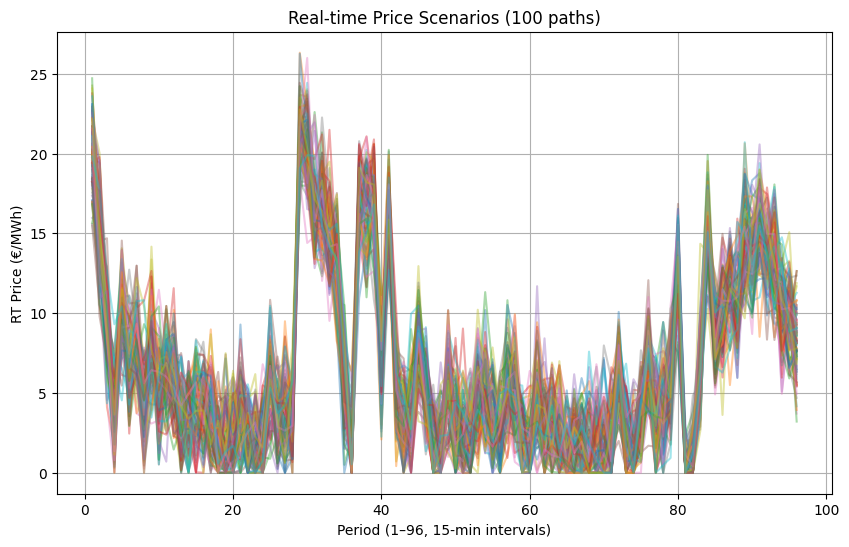

In [56]:
plt.figure(figsize=(10,6))
for w in W:
    vals = [rt_big[(t,j,w)] for t in range(1,25) for j in range(1,5)]
    plt.plot(range(1,97), vals, alpha=0.4)
plt.xlabel("Period (1–96, 15-min intervals)")
plt.ylabel("RT Price (€/MWh)")
plt.title(f"Real-time Price Scenarios ({len(W)} paths)")
plt.grid(True)
plt.show()

### 시나리오 생성 3

In [128]:
base_date = "20250601"
fn_base   = f"rdcdata/filteredcurve_{base_date}.csv"

# 기준일 원본 곡선 불러오기
df_base = pd.read_csv(fn_base, encoding="utf-8-sig")

# 저장 디렉토리 생성
out_dir = f"scenarios_{base_date}"
os.makedirs(out_dir, exist_ok=True)

num_scenarios = 100  # 시나리오 개수

for w in range(num_scenarios):
    df_scen = []

    for period in range(1,25):
        sub = df_base[df_base["Time Period"] == period]
        if sub.empty:
            continue

        # 공급/수요 따로 분리
        sup = sub[sub["GC"]=="V"].copy()
        dem = sub[sub["GC"]=="C"].copy()

        # 노이즈 주기 (±5%)
        sup["Amount"] = sup["Amount"] * (1 + np.random.normal(0,0.05,len(sup)))
        dem["Amount"] = dem["Amount"] * (1 + np.random.normal(0,0.05,len(dem)))

        # 결과 합치기
        df_scen.append(pd.concat([sup,dem]))

    # concat 후 CSV 저장
    df_out = pd.concat(df_scen).reset_index(drop=True)
    out_path = os.path.join(out_dir, f"curve_scen{w:03d}.csv")
    df_out.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ {num_scenarios}개 시나리오 생성 완료 → {out_dir}")

✅ 100개 시나리오 생성 완료 → scenarios_20250601


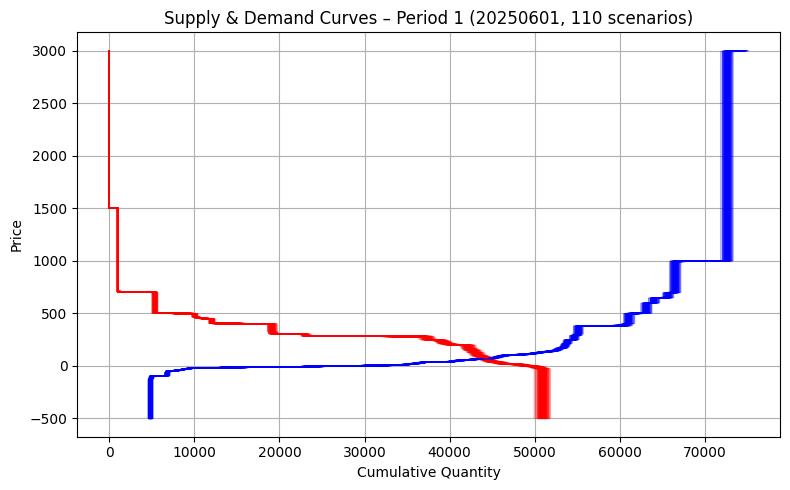

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

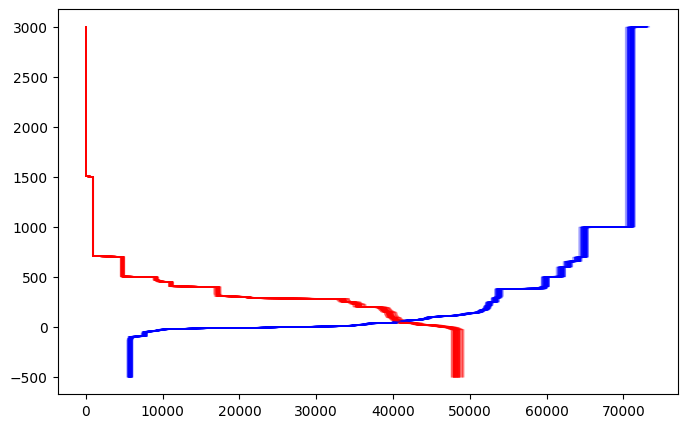

In [129]:
def load_curves_from_path(file_path, period):
    df = pd.read_csv(file_path, sep=',', encoding='utf-8-sig')
    mask   = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]
    if supply.empty or demand.empty:
        return None

    # 공급 곡선 집계
    s_agg = (supply.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()

    # 수요 곡선 집계
    d_agg = (demand.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
    pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
    price_grid  = np.linspace(pmin, pmax, 500)

    s_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(0, s_agg['CumulQty'].iloc[-1]))
    d_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(d_agg['CumulQty'].iloc[0], 0))

    supply_vals = s_func(price_grid)
    demand_vals = d_func(price_grid)
    return price_grid, supply_vals, demand_vals


# --------------------------
# 저장된 시나리오 불러오기
# --------------------------
date_str = "20250601"
scenario_dir = f"scenarios_{date_str}"
scenario_files = sorted(glob.glob(os.path.join(scenario_dir, "*.csv")))

# --------------------------
# 각 시간대마다 곡선 플롯
# --------------------------
for period in range(1,25):
    plt.figure(figsize=(8,5))
    any_plotted = False
    for fp in scenario_files:
        out = load_curves_from_path(fp, period)
        if out is None: continue
        price_grid, supply_vals, demand_vals = out
        plt.plot(supply_vals, price_grid, color="blue", alpha=0.3, lw=1)
        plt.plot(demand_vals, price_grid, color="red",  alpha=0.3, lw=1)
        any_plotted = True

    if not any_plotted:
        plt.close()
        continue

    plt.xlabel("Cumulative Quantity")
    plt.ylabel("Price")
    plt.title(f"Supply & Demand Curves – Period {period} ({date_str}, {len(scenario_files)} scenarios)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [130]:
# ---------------------------
# 기본 설정
# ---------------------------
base_date = "20250601"
scenario_dir = f"scenarios_{base_date}"  # 앞에서 만든 S&D 곡선 시나리오 폴더
scenario_files = sorted(glob.glob(os.path.join(scenario_dir, "*.csv")))
W = list(range(len(scenario_files)))     # 시나리오 개수

qini_big, qmax_big, lambda_da_big = {}, {}, {}
rt_big, pwf_big = {}, {}
valid_blocks_by_w = defaultdict(list)

wf_offer_grid = np.arange(0, 2000, 10)
B = 10  # stepwise block 수

# ---------------------------
# 기준일 발전량 / 가격 불러오기
# ---------------------------
df_pwf = pd.read_csv("co2freegeneration_filled.csv", sep=",")
df_pwf["datetime"] = pd.to_datetime(df_pwf["datetime"])
df_pwf["date"] = df_pwf["datetime"].dt.date
df_pwf["hour"] = df_pwf["datetime"].dt.hour

date_pd = pd.to_datetime(base_date)
sub_pwf = df_pwf[df_pwf["date"] == date_pd.date()]
pwf_base = {int(row["hour"])+1: row["value"]/20 for _,row in sub_pwf.iterrows()}

rt_files = sorted(glob.glob("rtdata/marginalpibc_2025*.1"))
fmatch = [f for f in rt_files if base_date in f]
df_rt = pd.read_csv(fmatch[0], sep=";", encoding="latin-1", skiprows=1, header=None)
df_rt = df_rt.dropna(how="all", axis=1)
df_rt.columns = ["Year","Month","Day","Period","Price1","Price2"][:df_rt.shape[1]]
df_rt = df_rt.dropna(subset=["Period","Price1"])
df_rt["Period"] = df_rt["Period"].astype(int)
rt_base = {}
for _, row in df_rt.iterrows():
    period = int(row["Period"])
    t = (period-1)//4 + 1
    j = (period-1)%4 + 1
    rt_base[(t,j)] = float(row["Price1"])/4

# ---------------------------
# 시나리오별로 합치기
# ---------------------------
for w, fp in enumerate(scenario_files):
    # --- 발전량 노이즈 (±5%)
    for t,v in pwf_base.items():
        pwf_big[(0,t,w)] = max(0, v*(1+np.random.normal(0,0.05)))

    # --- 실시간 가격 노이즈 (±2 €/MWh)
    for (t,j),v in rt_base.items():
        rt_big[(t,j,w)] = max(0, v+np.random.normal(0,2))

    # --- S&D 곡선 → RDC 변환 ---
    df = pd.read_csv(fp, encoding="utf-8-sig")
    for t in range(1,25):
        df_t = df[df["Time Period"] == t]
        sup  = df_t[df_t["GC"] == "V"]
        dem  = df_t[df_t["GC"] == "C"]
        if sup.empty or dem.empty:
            continue

        # 집계
        s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        s_agg["Cumul"] = s_agg["Amount"].cumsum()

        d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg["Price"], s_agg["Cumul"],
                       kind="previous", bounds_error=False, fill_value=(0,s_agg["Cumul"].iloc[-1]))
        d_f = interp1d(d_agg["Price"], d_agg["Cumul"],
                       kind="previous", bounds_error=False, fill_value=(d_agg["Cumul"].iloc[0],0))

        price_grid = np.linspace(min(s_agg["Price"].min(), d_agg["Price"].min()),
                                 max(s_agg["Price"].max(), d_agg["Price"].max()), 500)
        sv, dv = s_f(price_grid), d_f(price_grid)

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(price_grid, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 근사
        q_breaks = np.linspace(min(qv), max(qv), B+1)
        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue

            qini_big[(t,b,w)]      = q_low
            qmax_big[(t,b,w)]      = q_high - q_low
            lambda_da_big[(t,b,w)] = np.mean(np.array(pv)[mask])

            if qmax_big[(t,b,w)] > 0:
                valid_blocks_by_w[(t,w)].append(b)

    # 블록 정리
    for t in range(1,25):
        valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))

print(f"✅ 통합 시나리오 {len(W)}개 생성 완료")
print("예시 발전량:", list(pwf_big.items())[:3])
print("예시 가격:", list(rt_big.items())[:6])
print("예시 RDC:", list(qini_big.items())[:3])


NameError: name 'compute_rdc_by_sign_change' is not defined

## 최적화 모델

In [57]:
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500
Δt = 0.25

In [107]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# ---------- 1단계(H&N) ----------
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                  vtype=GRB.BINARY, name="u")

# qvar, p_bid도 w에 종속(DA 기대값을 w로 평균)
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                      lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# ESS on/off (H&N)
u_c = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

# LDR 계수(공통)
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
# DA 수익
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

# RT 수익
RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[t,j,w] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

In [108]:
# ---------- 제약식 (통일 버전) ----------
# 모든 (t,j,w)에 대해 균형
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)   # 15분 평균 풍력
                + p_d[(t,j,w)] - p_c[(t,j,w)]                    # ESS 순발전
                - p_bid[t]/4.0,                                  # DA 약속의 1/4
                name=f"rt_balance_{t}_{j}_w{w}"
            )
# (6c) 매 시각 블록 하나 선택 (1단계 공통)
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
                    name=f"one_block_{t}")

# # (6d) qvar ≤ qmax * u  (모든 w에서 성립 → qmax_big[(t,b,w)] 사용, qvar은 w-비의존)
# for w in W:
#     for t in T:
#         for b in valid_blocks[t]:
#             model.addConstr(
#                 qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
#                 name=f"qvar_max_{t}_{b}_w{w}"
#             )
for w in W:
    for t in T:
        for b in valid_blocks_by_w.get((t,w), []):
            model.addConstr(
                qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
                name=f"qvar_max_{t}_{b}_w{w}"
            )

# (6e) p_bid 정의 (1단계 공통결정, 기대값 기반)
#  E[qini] = Σ_w rho_w[w] * qini_big[(t,b,w)]
# mu_qini = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W)
#            for t in T for b in valid_blocks[t]}

# for t in T:
#     model.addConstr(
#         p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
#                                 for b in valid_blocks[t]),
#         name=f"p_bid_def_{t}"
#     )
# (6e) p_bid 정의 (qini는 시나리오와 무관 → 첫 시나리오 값 사용)
mu_qini = {
    (t,b): sum(rho_w[w] * qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
    for t in T for b in valid_blocks[t]
}

for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )
# (6h, 6i) LDR (2단계, w-의존)  —— delta_rt 대신 실시간가격 rt_big 사용
#     p_c = u_c * (p̂_c + D_c * λ_rt),   p_d = u_d * (p̂_d + D_d * λ_rt)
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * (p_hat_c[(t,j)] + D_c[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * (p_hat_d[(t,j)] + D_d[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# (6k) 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)],
                            name=f"pc_bigm_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)],
                            name=f"pd_bigm_{t}_{j}_w{w}")

# (6j) SOC 전이 (2단계, w-의존)
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t == 1 and j == 1)
                    else (E_q[(t-1,4,w)] if j == 1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# (6g) DA vs RT 약속량 경계 (1단계 p_bid[t] vs 2단계 실현치)
#  풍력(gen) 시나리오 인덱스는 triplet_of[w][1] 이나,
#  이미 pwf_big[(i,t,w)] 로 매핑되어 있으니 그걸 그대로 사용
for w in W:
    for t in T:
        # 상한: 풍력 발전 + 방전
        rhs = 1000 + gp.quicksum(p_d[(t,j,w)] for j in J)
        # 하한: -충전
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t],
                        name=f"bid_low_{t}_w{w}")
        # 상한
        model.addConstr(p_bid[t] <= rhs, name=f"bid_up_sync_{t}_w{w}")

# 옵션 파라미터
model.Params.MIPGap = 0.00000002
# model.Params.TimeLimit = 3600
# model.Params.Heuristics = 0.1
# model.feasRelaxS(0, True, False, True)
model.optimize()

Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 520944 rows, 48552 columns and 1108820 nonzeros
Model fingerprint: 0xa4e6598d
Model has 19200 quadratic constraints
Variable types: 43584 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [2e-03, 3e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [2e-05, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 486469 rows and 16659 columns
Presolve time: 1.49s
Presolved: 53147 rows, 33045 columns, 245816 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 30256 continuous, 2789 integer (2758 binary)
Root relaxation presolved: 38497 rows, 18011 columns, 233932 nonzeros

Deterministic concurre

In [109]:
Z_RP = model.ObjVal

In [110]:
# 선택된 블록
chosen_b = {t: max(valid_blocks[t], key=lambda b: u[t,b].X) for t in T}

# DA 입찰
p_bid_sol = {t: p_bid[t].X for t in T}

# ESS 제어 (시나리오 평균/첫 시나리오 예시)
p_c_mean = {(t,j): sum(rho_w[w]*p_c[t,j,w].X for w in W) for t in T for j in J}
p_d_mean = {(t,j): sum(rho_w[w]*p_d[t,j,w].X for w in W) for t in T for j in J}
E_mean   = {(t,j): sum(rho_w[w]*E_q[t,j,w].X for w in W) for t in T for j in J}
qini_sum = sum(mu_qini[(t,b)] for b in valid_blocks[t])
qvar_sum = sum(qvar[(t,b)]     for b in valid_blocks[t])


In [111]:
import csv
with open("solution_da_rt09291359.csv","w",newline="",encoding="utf-8-sig") as f:
    wtr = csv.writer(f)
    wtr.writerow(["t","chosen_b","p_bid","p_c_mean","p_d_mean","E_mean"])
    for t in T:
        for j in J:
            wtr.writerow([t, chosen_b[t], p_bid_sol[t], p_c_mean[t,j], p_d_mean[t,j], E_mean[t,j]])
print("saved")


saved


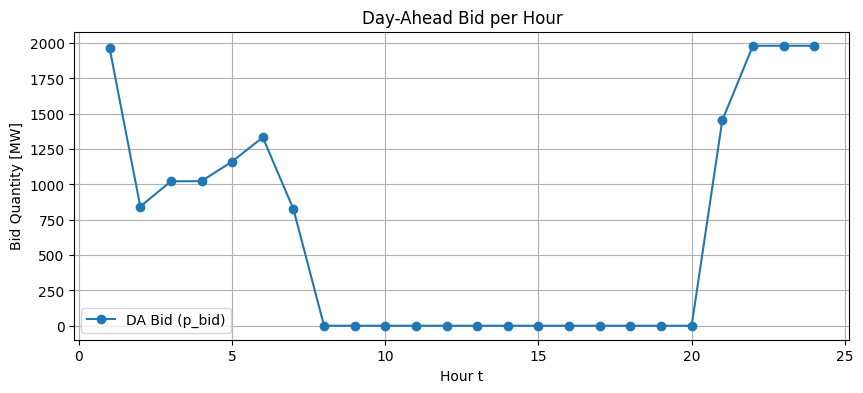

In [112]:
plt.figure(figsize=(10,4))
plt.plot(list(T), [p_bid_sol[t] for t in T], marker="o", label="DA Bid (p_bid)")
plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Day-Ahead Bid per Hour")
plt.grid(True)
plt.legend()
plt.show()

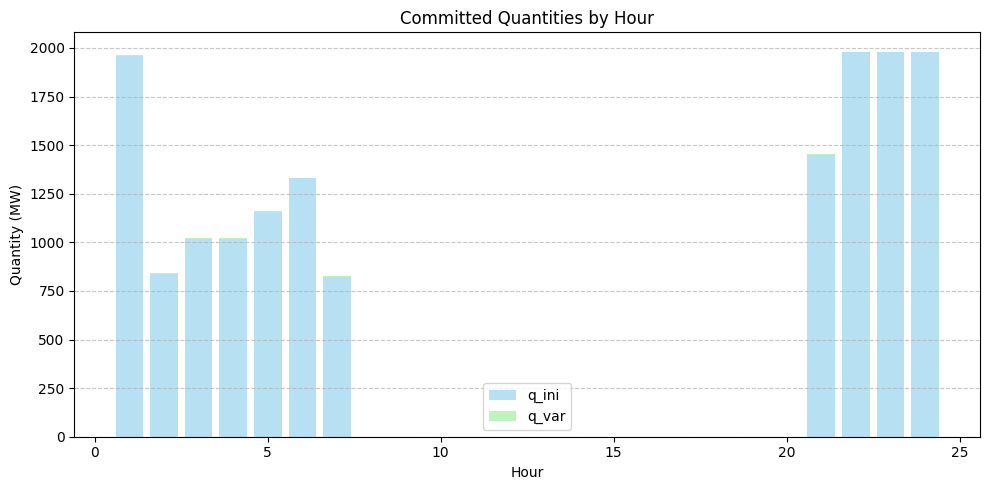

In [113]:
q_ini_hour = []
q_var_hour = []

for t in T:
    qini_sum = sum(u[t,b].X * mu_qini[(t,b)] for b in valid_blocks[t])
    qvar_sum = sum(qvar[t,b].X           for b in valid_blocks[t])
    q_ini_hour.append(qini_sum)
    q_var_hour.append(qvar_sum)

plt.figure(figsize=(10,5))
plt.bar(T, q_ini_hour, color="skyblue", alpha=0.6, label="q_ini")
plt.bar(T, q_var_hour, bottom=q_ini_hour, color="lightgreen", alpha=0.6, label="q_var")

plt.xlabel("Hour")
plt.ylabel("Quantity (MW)")
plt.title("Committed Quantities by Hour")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



In [114]:
# RDC 시나리오 집합 S(=10개)와 가중치 rho_rdc[s] (균등이면 1/|S|)
# triples[w] = (rdc_s, gen_s, rt_s)
S_rdc = list(range(len(date_range)))   # 10
S_rdc = list(range(100))   # 10

rho_rdc = {s: 1/len(S_rdc) for s in S_rdc}

# RDC만 평균 (gen/rt는 평균하지 않음)
mu_lambda_RDC = {(t,b): sum(rho_rdc[s]*lambda_da_scen_final[(t,b,s)] for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qini_RDC   = {(t,b): sum(rho_rdc[s]*qini_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qmax_RDC   = {(t,b): sum(rho_rdc[s]*qmax_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}

In [115]:
for t in T:
    for b in valid_blocks[t]:
        # 아무 시나리오 하나만 골라도 동일 (예: 첫 번째 시나리오 s=0)
        mu_qini_RDC[(t,b)] = qini_scen_final[(t,b,0)]
        mu_qmax_RDC[(t,b)] = qmax_scen_final[(t,b,0)]

In [116]:
# ---------------------------------------
# EV model: RDC만 EV, 나머지는 시나리오 유지
# ---------------------------------------
EV = gp.Model("EV_RDC_only")

# 1단계 변수
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")

u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2단계 변수 (w 의존)
p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# --- 목적함수 ---
# DA: RDC 평균만 사용
DA_ev = gp.quicksum(
    mu_lambda_RDC[(t,b)] * (u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b])
    for t in T for b in valid_blocks[t]
)

# RT: GEN/RT는 시나리오별
RT_ev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_e[t,j,w] - p_bid_e[t]/4.0)
        for j in J
    )
    for w in W for t in T
)

EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# --- 제약 ---
for t in T:
    # 블록 하나만 선택
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1)

    # bid 정의
    EV.addConstr(
        p_bid_e[t] == gp.quicksum(u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b]
                                  for b in valid_blocks[t])
    )

    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax_RDC[(t,b)] * u_e[t,b])

# 2단계 (시나리오별 balance, SOC, etc.)
for w in W:
    for t in T:
        for j in J:
            EV.addConstr(
                p_c_e[t,j,w] == u_c_e[t,j] * (p_hat_c_e[t,j] + D_c_e[t,j]*rt_big[(t,j,w)])
            )
            EV.addConstr(
                p_d_e[t,j,w] == u_d_e[t,j] * (p_hat_d_e[t,j] + D_d_e[t,j]*rt_big[(t,j,w)])
            )
            EV.addConstr(
                p_b_e[t,j,w] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                + p_d_e[t,j,w] - p_c_e[t,j,w] - p_bid_e[t]/4.0
            )

            prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
            EV.addConstr(E_e[t,j,w] == prev + Δt*(eta_c*p_c_e[t,j,w] - p_d_e[t,j,w]/eta_d))

    # bid 경계
    for t in T:
        EV.addConstr(-gp.quicksum(p_c_e[t,j,w] for j in J) <= p_bid_e[t])
        EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[t,j,w] for j in J))
EV.Params.MIPGap = 0.00000002
EV.optimize()
Z_EV_RDC = EV.ObjVal


Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 28824 rows, 48552 columns and 124580 nonzeros
Model fingerprint: 0x2724c529
Model has 19200 quadratic constraints
Variable types: 43584 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [2e-03, 3e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [2e-05, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 3720 rows and 11616 columns
Presolve time: 0.32s
Presolved: 43776 rows, 38088 columns, 244478 nonzeros
Presolved model has 768 SOS constraint(s)
Variable types: 32808 continuous, 5280 integer (5280 binary)
Found heuristic solution: objective 216872.69442
Deterministic concurrent LP optimizer: primal an

In [117]:
EEV = gp.Model("EEV_RDC_eval")

# 2단계만 변수
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max)
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max)
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max)
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0)

# EV의 1단계 해 고정값 사용
DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_e[t,b].X * qini_big[(t,b,w)] + qv_e[t,b].X)
        for b in valid_blocks[t] if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[t,j,w] - p_bid_e[t].X/4.0)
        for j in J
    )
    for w in W for t in T
)
EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

# LDR/균형/SOC/경계 — EV의 u_c,u_d,p_hat,D,p_bid 를 **값**으로 사용
for w in W:
  for t in T:
    for j in J:
      EEV.addConstr(p_c2[t,j,w] == u_c_e[t,j].X*(p_hat_c_e[t,j].X + D_c_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_d2[t,j,w] == u_d_e[t,j].X*(p_hat_d_e[t,j].X + D_d_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_b2[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[t,j,w] - p_c2[t,j,w]
                    - p_bid_e[t].X/4.0)
      prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
      EEV.addConstr(E2[t,j,w] == prev + Δt*(eta_c*p_c2[t,j,w] - p_d2[t,j,w]/eta_d))
  for t in T:
      EEV.addConstr(-gp.quicksum(p_c2[t,j,w] for j in J) <= p_bid_e[t].X)
      EEV.addConstr(p_bid_e[t].X <= 1000 + gp.quicksum(p_d2[t,j,w] for j in J))
EEV.Params.MIPGap = 0.00000002
EEV.optimize()
Z_EEV = EEV.ObjVal

Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 10.0.2 build v10.0.2rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 43200 rows, 38400 columns and 105500 nonzeros
Model fingerprint: 0x3f9590c6
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [2e-05, 3e-01]
  Bounds range     [5e+02, 2e+03]
  RHS range        [5e-13, 2e+03]
Presolve removed 43200 rows and 38400 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.8846817e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.02 work units)
Optimal objective  4.884681671e+05


In [118]:
VSS_RDC = Z_RP - Z_EEV
print(f"Z_RP    = {Z_RP:,.2f}")
print(f"Z_EEV   = {Z_EEV:,.2f}")
print(f"VSS(RDC)= {VSS_RDC:,.2f}")

Z_RP    = 573,037.91
Z_EEV   = 488,468.17
VSS(RDC)= 84,569.74


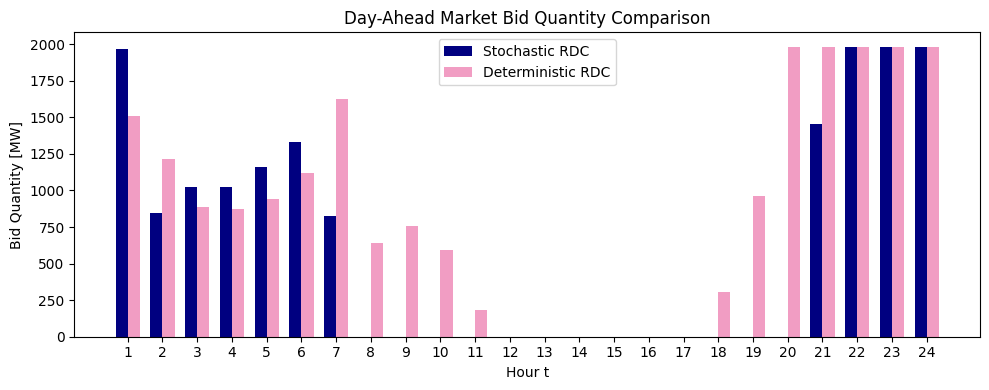

In [120]:
# --- p_bid 비교: RP 최적해 vs EV 해 ---
p_bid_RP  = [p_bid[t].X    for t in T]   # Recourse/RP 해
p_bid_EEV = [p_bid_e[t].X  for t in T]   # EV 기반 해 (EEV 평가)
x = np.arange(len(T))
width = 0.35

fig, ax = plt.subplots(figsize=(10,4))

# 색상 지정: 핑크(#ffb6c1), 하늘색(#87ceeb)
ax.bar(x - width/2, p_bid_RP,  width, label="Stochastic RDC", color="#000080")
ax.bar(x + width/2, p_bid_EEV, width, label="Deterministic RDC", color="#f19DC3")
# ax.bar(x - width/2, p_bid_RP,  width, label="Stochastic RDC", color="#ffb6c1")
# ax.bar(x + width/2, p_bid_EEV, width, label="Deterministic RDC", color="#87ceeb")

ax.set_xticks(x)
ax.set_xticklabels(T)
ax.set_xlabel("Hour t")
ax.set_ylabel("Bid Quantity [MW]")
ax.set_title("Day-Ahead Market Bid Quantity Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 0930

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict
from itertools import product
import gurobipy as gp
from gurobipy import GRB
import itertools
from datetime import datetime, timedelta  
import glob

In [2]:
# --- RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

In [3]:
base_date = "20250601"
fn_base   = f"rdcdata/filteredcurve_{base_date}.csv"

# 기준일 원본 곡선 불러오기
df_base = pd.read_csv(fn_base, encoding="utf-8-sig")

# 저장 디렉토리 생성
out_dir = f"scenariosuniform2_{base_date}"
os.makedirs(out_dir, exist_ok=True)

num_scenarios = 100  # 시나리오 개수
noise_level = 0.2   # ±5%

for w in range(num_scenarios):
    df_scen = []
    for period in range(1,25):
        sub = df_base[df_base["Time Period"] == period]
        if sub.empty:
            continue

        # 공급/수요 따로 분리
        sup = sub[sub["GC"]=="V"].copy()
        dem = sub[sub["GC"]=="C"].copy()
        eps = np.random.normal(0, 0.1)  # 공통 충격
        # Uniform 노이즈 주기 (±5%)
        sup["Amount"] = sup["Amount"] * (1  + eps + np.random.uniform(-noise_level, noise_level, len(sup)))
        dem["Amount"] = dem["Amount"] * (1 - eps + np.random.uniform(-noise_level, noise_level, len(dem)))

        # 결과 합치기
        df_scen.append(pd.concat([sup,dem]))

    # concat 후 CSV 저장
    df_out = pd.concat(df_scen).reset_index(drop=True)
    out_path = os.path.join(out_dir, f"curve_scen{w:03d}.csv")
    df_out.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ {num_scenarios}개 시나리오 생성 완료 (uniform noise) → {out_dir}")


✅ 100개 시나리오 생성 완료 (uniform noise) → scenariosuniform2_20250601


In [4]:
df_pwf = pd.read_csv("co2freegeneration_filled.csv", sep=",")
df_pwf["datetime"] = pd.to_datetime(df_pwf["datetime"])
df_pwf["date"] = df_pwf["datetime"].dt.date
df_pwf["hour"] = df_pwf["datetime"].dt.hour

date_pd = pd.to_datetime(base_date)
sub_pwf = df_pwf[df_pwf["date"] == date_pd.date()]
pwf_base = {int(row["hour"])+1: row["value"]/20 for _,row in sub_pwf.iterrows()}

rt_files = sorted(glob.glob("rtdata/marginalpibc_2025*.1"))
fmatch = [f for f in rt_files if base_date in f]
df_rt = pd.read_csv(fmatch[0], sep=";", encoding="latin-1", skiprows=1, header=None)
df_rt = df_rt.dropna(how="all", axis=1)
df_rt.columns = ["Year","Month","Day","Period","Price1","Price2"][:df_rt.shape[1]]
df_rt = df_rt.dropna(subset=["Period","Price1"])
df_rt["Period"] = df_rt["Period"].astype(int)
rt_base = {}
for _, row in df_rt.iterrows():
    period = int(row["Period"])
    t = (period-1)//4 + 1
    j = (period-1)%4 + 1
    rt_base[(t,j)] = float(row["Price1"])/4

In [5]:
scenario_dir   = f"scenariosuniform2_{base_date}"
scenario_files = sorted(glob.glob(os.path.join(scenario_dir, "*.csv")))
W = list(range(num_scenarios))  # 0..999
rho_w = {w: 1/len(W) for w in W}
wf_offer_grid = np.arange(0, 2000,10)
B = 200  # 블록 수
qini_big, qmax_big, lambda_da_big = {}, {}, {}
pwf_big, rt_big = {}, {}
valid_blocks_by_w = defaultdict(list)

# ---------------------------
# 시나리오별로 합치기
# ---------------------------
for w, fp in enumerate(scenario_files):
    # --- 발전량 노이즈 (Uniform ±5%) ---
    for t,v in pwf_base.items():
        noise = np.random.uniform(-0.05, 0.05)  # [-5%, +5%]
        pwf_big[(0,t,w)] = max(0, v*(1+noise))

    # --- 실시간 가격 노이즈 (Uniform ±2 €/MWh) ---
    for (t,j),v in rt_base.items():
        noise = np.random.uniform(-0.05, 0.05)  # [-10%, +10%]
        rt_big[(t,j,w)] = max(0, v*(1+noise))

    # --- S&D 곡선 → RDC 변환 ---
    df = pd.read_csv(fp, encoding="utf-8-sig")
    for t in range(1,25):
        df_t = df[df["Time Period"] == t]
        sup  = df_t[df_t["GC"] == "V"]
        dem  = df_t[df_t["GC"] == "C"]
        if sup.empty or dem.empty:
            continue

        # 집계
        s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        s_agg["Cumul"] = s_agg["Amount"].cumsum()

        d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg["Price"], s_agg["Cumul"],
                       kind="previous", bounds_error=False, fill_value=(0,s_agg["Cumul"].iloc[-1]))
        d_f = interp1d(d_agg["Price"], d_agg["Cumul"],
                       kind="previous", bounds_error=False, fill_value=(d_agg["Cumul"].iloc[0],0))

        price_grid = np.linspace(min(s_agg["Price"].min(), d_agg["Price"].min()),
                                 max(s_agg["Price"].max(), d_agg["Price"].max()), 500)
        sv, dv = s_f(price_grid), d_f(price_grid)

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(price_grid, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 근사
        q_breaks = np.linspace(min(qv), max(qv), B+1)
        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue

            qini_big[(t,b,w)]      = q_low
            qmax_big[(t,b,w)]      = q_high - q_low
            lambda_da_big[(t,b,w)] = np.mean(np.array(pv)[mask])

            if qmax_big[(t,b,w)] > 0:
                valid_blocks_by_w[(t,w)].append(b)

    # 블록 정리
    for t in range(1,25):
        valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))

print(f"✅ 통합 시나리오 {len(W)}개 생성 완료 (uniform noise)")
print("예시 발전량:", list(pwf_big.items())[:3])
print("예시 가격:", list(rt_big.items())[:6])
print("예시 RDC:", list(qini_big.items())[:3])

✅ 통합 시나리오 100개 생성 완료 (uniform noise)
예시 발전량: [((0, 1, 0), 897.7817644637012), ((0, 2, 0), 900.4955296990565), ((0, 3, 0), 782.6340863523252)]
예시 가격: [((1, 1, 0), 20.31668765315197), ((1, 2, 0), 14.308186497742089), ((1, 3, 0), 9.463062042429982), ((1, 4, 0), 3.4044885159984353), ((2, 1, 0), 10.455059403087228), ((2, 2, 0), 6.850984313015508)]
예시 RDC: [((1, 0, 0), 0.0), ((1, 1, 0), 9.95), ((1, 2, 0), 19.9)]


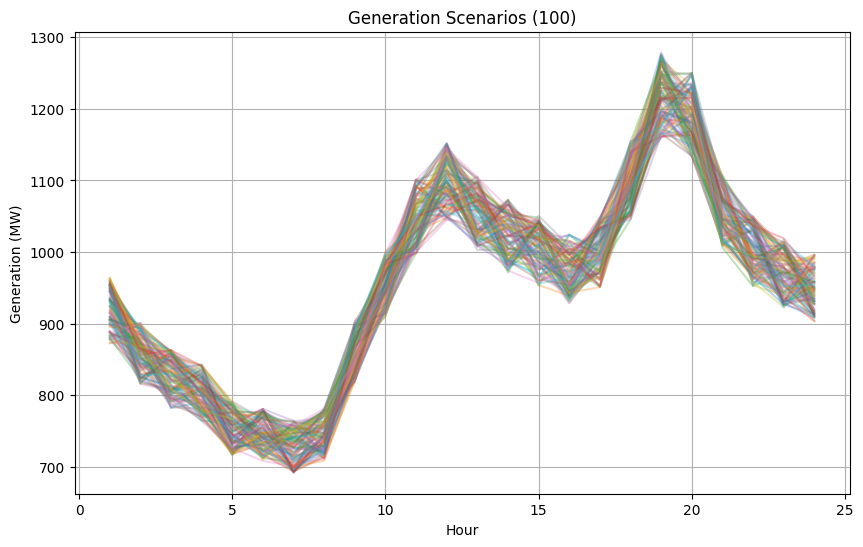

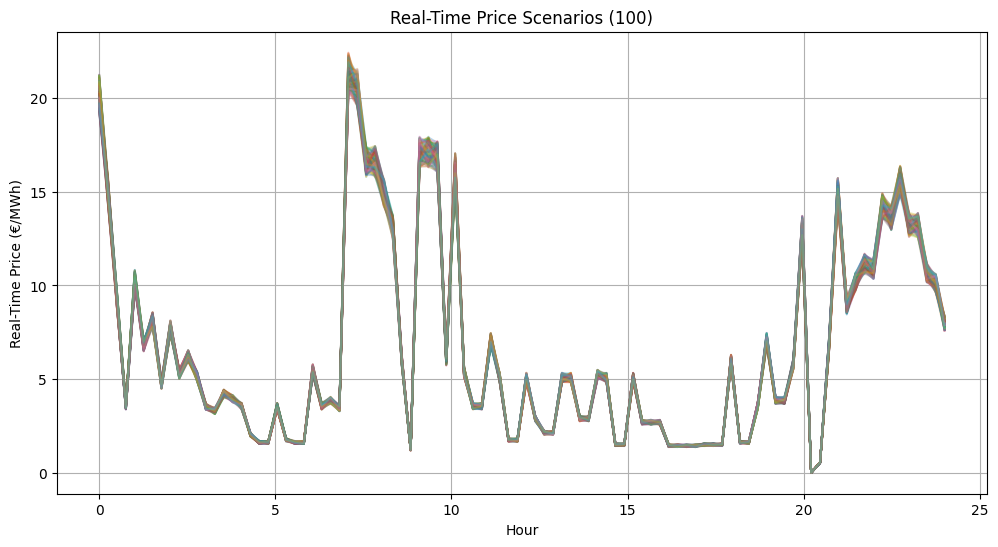

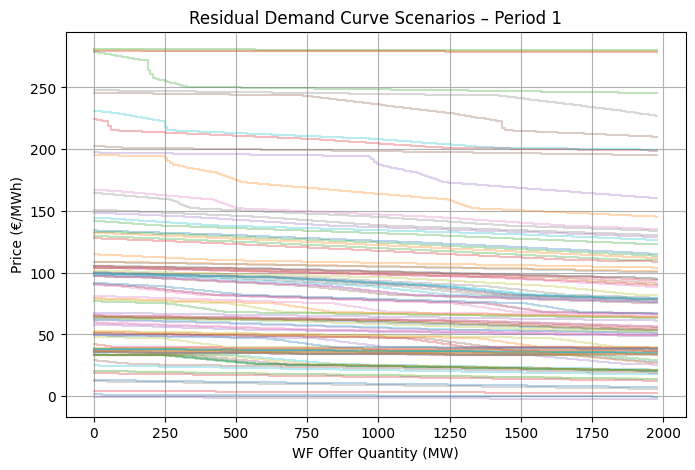

In [14]:
plt.figure(figsize=(10,6))
for w in W:
    vals = [pwf_big[(0,t,w)] for t in range(1,25)]
    plt.plot(range(1,25), vals, alpha=0.3)
plt.xlabel("Hour")
plt.ylabel("Generation (MW)")
plt.title("Generation Scenarios (100)")
plt.grid(True)
plt.show()
plt.figure(figsize=(12,6))
for w in W:
    vals = [rt_big[(t,j,w)] for t in range(1,25) for j in range(1,5)]
    plt.plot(np.linspace(0,24,len(vals)), vals, alpha=0.3)
plt.xlabel("Hour")
plt.ylabel("Real-Time Price (€/MWh)")
plt.title("Real-Time Price Scenarios (100)")
plt.grid(True)
plt.show()
period = 1
plt.figure(figsize=(8,5))

for w in W:
    q_steps, p_steps = [], []

    for b in valid_blocks_by_w.get((period,w), []):
        q_low  = qini_big[(period,b,w)]
        q_high = q_low + qmax_big[(period,b,w)]
        lam    = lambda_da_big[(period,b,w)]

        # stepwise 구간 추가
        q_steps.extend([q_low, q_high])
        p_steps.extend([lam, lam])

    if p_steps:  # 빈 리스트 아니면 그림
        plt.step(q_steps, p_steps, where="post", alpha=0.3)

plt.xlabel("WF Offer Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"Residual Demand Curve Scenarios – Period {period}")
plt.grid(True)
plt.show()


### 시나리오2

In [3]:
base_date = "20250601"
fn_base   = f"rdcdata/filteredcurve_{base_date}.csv"

# 기준일 원본 곡선 불러오기
df_base = pd.read_csv(fn_base, encoding="utf-8-sig")

# 저장 디렉토리 생성
out_dir = f"scenariosuniform_{base_date}"
os.makedirs(out_dir, exist_ok=True)

num_scenarios = 100  # 시나리오 개수
noise_level = 0.05   # ±5%

for w in range(num_scenarios):
    df_scen = []
    for period in range(1,25):
        sub = df_base[df_base["Time Period"] == period]
        if sub.empty:
            continue

        # 공급/수요 따로 분리
        sup = sub[sub["GC"]=="V"].copy()
        dem = sub[sub["GC"]=="C"].copy()

        # Uniform 노이즈 주기 (±5%)
        sup["Amount"] = sup["Amount"] * (1 + np.random.uniform(-noise_level, noise_level, len(sup)))
        dem["Amount"] = dem["Amount"] * (1 + np.random.uniform(-noise_level, noise_level, len(dem)))

        # 결과 합치기
        df_scen.append(pd.concat([sup,dem]))

    # concat 후 CSV 저장
    df_out = pd.concat(df_scen).reset_index(drop=True)
    out_path = os.path.join(out_dir, f"curve_scen{w:03d}.csv")
    df_out.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ {num_scenarios}개 시나리오 생성 완료 (uniform noise) → {out_dir}")


✅ 100개 시나리오 생성 완료 (uniform noise) → scenariosuniform_20250601


In [4]:
df_pwf = pd.read_csv("co2freegeneration_filled.csv", sep=",")
df_pwf["datetime"] = pd.to_datetime(df_pwf["datetime"])
df_pwf["date"] = df_pwf["datetime"].dt.date
df_pwf["hour"] = df_pwf["datetime"].dt.hour

date_pd = pd.to_datetime(base_date)
sub_pwf = df_pwf[df_pwf["date"] == date_pd.date()]
pwf_base = {int(row["hour"])+1: row["value"]/20 for _,row in sub_pwf.iterrows()}

rt_files = sorted(glob.glob("rtdata/marginalpibc_2025*.1"))
fmatch = [f for f in rt_files if base_date in f]
df_rt = pd.read_csv(fmatch[0], sep=";", encoding="latin-1", skiprows=1, header=None)
df_rt = df_rt.dropna(how="all", axis=1)
df_rt.columns = ["Year","Month","Day","Period","Price1","Price2"][:df_rt.shape[1]]
df_rt = df_rt.dropna(subset=["Period","Price1"])
df_rt["Period"] = df_rt["Period"].astype(int)
rt_base = {}
for _, row in df_rt.iterrows():
    period = int(row["Period"])
    t = (period-1)//4 + 1
    j = (period-1)%4 + 1
    rt_base[(t,j)] = float(row["Price1"])/4

In [5]:
scenario_dir   = f"scenariosuniform2_{base_date}"
scenario_files = sorted(glob.glob(os.path.join(scenario_dir, "*.csv")))
W = list(range(num_scenarios))  # 0..999
rho_w = {w: 1/len(W) for w in W}
wf_offer_grid = np.arange(0, 2000,10)
B = 200  # 블록 수
qini_big, qmax_big, lambda_da_big = {}, {}, {}
pwf_big, rt_big = {}, {}
valid_blocks_by_w = defaultdict(list)

# ---------------------------
# 시나리오별로 합치기
# ---------------------------
for w, fp in enumerate(scenario_files):
    # --- 발전량 노이즈 (Uniform ±5%) ---
    for t,v in pwf_base.items():
        noise = np.random.uniform(-0.05, 0.05)  # [-5%, +5%]
        pwf_big[(0,t,w)] = max(0, v*(1+noise))

    # --- 실시간 가격 노이즈 (Uniform ±2 €/MWh) ---
    for (t,j),v in rt_base.items():
        noise = np.random.uniform(-0.05, 0.05)  # [-10%, +10%]
        rt_big[(t,j,w)] = max(0, v*(1+noise))

    # --- S&D 곡선 → RDC 변환 ---
    df = pd.read_csv(fp, encoding="utf-8-sig")
    for t in range(1,25):
        df_t = df[df["Time Period"] == t]
        sup  = df_t[df_t["GC"] == "V"]
        dem  = df_t[df_t["GC"] == "C"]
        if sup.empty or dem.empty:
            continue

        # 집계
        s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        s_agg["Cumul"] = s_agg["Amount"].cumsum()

        d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
        d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg["Price"], s_agg["Cumul"],
                       kind="previous", bounds_error=False, fill_value=(0,s_agg["Cumul"].iloc[-1]))
        d_f = interp1d(d_agg["Price"], d_agg["Cumul"],
                       kind="previous", bounds_error=False, fill_value=(d_agg["Cumul"].iloc[0],0))

        price_grid = np.linspace(min(s_agg["Price"].min(), d_agg["Price"].min()),
                                 max(s_agg["Price"].max(), d_agg["Price"].max()), 500)
        sv, dv = s_f(price_grid), d_f(price_grid)

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(price_grid, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 근사
        q_breaks = np.linspace(min(qv), max(qv), B+1)
        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue

            qini_big[(t,b,w)]      = q_low
            qmax_big[(t,b,w)]      = q_high - q_low
            lambda_da_big[(t,b,w)] = np.mean(np.array(pv)[mask])

            if qmax_big[(t,b,w)] > 0:
                valid_blocks_by_w[(t,w)].append(b)

    # 블록 정리
    for t in range(1,25):
        valid_blocks_by_w[(t,w)] = sorted(set(valid_blocks_by_w[(t,w)]))

print(f"✅ 통합 시나리오 {len(W)}개 생성 완료 (uniform noise)")
print("예시 발전량:", list(pwf_big.items())[:3])
print("예시 가격:", list(rt_big.items())[:6])
print("예시 RDC:", list(qini_big.items())[:3])

✅ 통합 시나리오 100개 생성 완료 (uniform noise)
예시 발전량: [((0, 1, 0), 907.4446081990765), ((0, 2, 0), 832.4691233121489), ((0, 3, 0), 786.9810435961693)]
예시 가격: [((1, 1, 0), 19.669674213136332), ((1, 2, 0), 15.709175623099226), ((1, 3, 0), 9.477443253149087), ((1, 4, 0), 3.6645057908196064), ((2, 1, 0), 9.985239729179378), ((2, 2, 0), 6.68819606331443)]
예시 RDC: [((1, 0, 0), 0.0), ((1, 1, 0), 9.95), ((1, 2, 0), 19.9)]


In [15]:
valid_blocks = {t: [] for t in range(1,25)}
for (t,b,w), val in qmax_big.items():
    if val > 0:
        valid_blocks[t].append(b)
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

In [1]:
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500
# pc_max, pd_max  = 1000, 1000

Δt = 0.25

In [2]:
S = list(range(100))                        # 시나리오 index
T = list(range(1, 25))                                  # 시간
I = [0]
J = [1,2,3,4]
Δt = 0.25
rho_w = {s: 1/len(S) for s in S}        

In [3]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# ---------- 1단계(H&N) ----------
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                  vtype=GRB.BINARY, name="u")

qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                      lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# ESS on/off (H&N)
u_c = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

# LDR 계수(공통)
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[(t,j,w)] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

# ---------- 제약식 ----------
# (6b) 실시간 균형
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                + p_d[(t,j,w)] - p_c[(t,j,w)]
                - p_bid[t]/4.0,
                name=f"rt_balance_{t}_{j}_w{w}"
            )

# (6c) 매 시각 블록 하나 선택
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
                    name=f"one_block_{t}")

# # (6d) qvar 상한
# for w in W:
#     for t in T:
#         for b in valid_blocks_by_w.get((t,w), []):
#             model.addConstr(
#                 qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
#                 name=f"qvar_max_{t}_{b}_w{w}"
#             )
# (6d) qvar 상한
for w in W:
    for t in T:
        for b in valid_blocks_by_w.get((t,w), []):
            model.addConstr(
                qvar[t,b] <= 10,
                name=f"qvar_max_{t}_{b}_w{w}"
            )
# (6e) p_bid 정의 (평균 qini 사용)
mu_qini = {
    (t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
    for t in T for b in valid_blocks[t]
}
for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )

# (6h), (6i) LDR
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * (p_hat_c[(t,j)] + D_c[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * (p_hat_d[(t,j)] + D_d[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# (6k) 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)], name=f"pc_bigm_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)], name=f"pd_bigm_{t}_{j}_w{w}")

# (6j) SOC 전이
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t == 1 and j == 1)
                    else (E_q[(t-1,4,w)] if j == 1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# (6g) DA vs RT 경계
for w in W:
    for t in T:
        rhs = gp.quicksum(pwf_big[(i,t,w)] for i in I) + gp.quicksum(p_d[(t,j,w)] for j in J)
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t],
                        name=f"bid_low_{t}_w{w}")
        model.addConstr(p_bid[t] <= rhs, name=f"bid_up_{t}_w{w}")

# (6l), (6m) 충/방전 용량 상한
for w in W:
    for t in T:
        model.addConstr(
            gp.quicksum(D_c[(t,j)] * rt_big[(t,j,w)] + p_hat_c[(t,j)] for j in J)
            <= pc_max,
            name=f"cap_charge_{t}_w{w}"
        )
        model.addConstr(
            gp.quicksum(D_d[(t,j)] * rt_big[(t,j,w)] + p_hat_d[(t,j)] for j in J)
            <= pd_max,
            name=f"cap_discharge_{t}_w{w}"
        )

# ---------- 옵션 ----------
model.Params.MIPGap = 0.005
model.optimize()
Z_RP = model.ObjVal


NameError: name 'gp' is not defined

In [4]:
def build_and_solve_EV_RDC():
    m = gp.Model("EV_RDC_only")

    # ---------- 블록 집합 ----------
    valid_blocks_EV = {
        t: sorted({b for (tt,b,ww) in qini_big.keys() if tt == t})
        for t in T
    }

    # ---------- 평균 파라미터 ----------
    mu_qini = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W if (t,b,w) in qini_big)
               for t in T for b in valid_blocks_EV[t]}
    mu_qmax = {(t,b): sum(rho_w[w]*qmax_big[(t,b,w)] for w in W if (t,b,w) in qmax_big)
               for t in T for b in valid_blocks_EV[t]}
    mu_lambda = {(t,b): sum(rho_w[w]*lambda_da_big[(t,b,w)] for w in W if (t,b,w) in lambda_da_big)
                 for t in T for b in valid_blocks_EV[t]}

    # ---------- 1단계 ----------
    u_ev     = m.addVars([(t,b) for t in T for b in valid_blocks_EV[t]], vtype=GRB.BINARY, name="u")
    qvar_ev  = m.addVars([(t,b) for t in T for b in valid_blocks_EV[t]], lb=0.0, name="qvar")
    p_bid_ev = m.addVars(T, lb=0.0, name="p_bid")

    u_c_ev = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
    u_d_ev = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

    # ---------- 2단계 ----------
    p_c_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
    p_d_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
    E_q_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
    p_b_ev = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

    p_hat_c_ev = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
    p_hat_d_ev = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
    D_c_ev     = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
    D_d_ev     = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

    # ---------- 목적함수 ----------
    DA_rev_EV = gp.quicksum(
        mu_lambda[(t,b)] * (u_ev[t,b]*mu_qini[(t,b)] + qvar_ev[t,b])
        for t in T for b in valid_blocks_EV[t]
    )
    RT_rev_EV = gp.quicksum(
        rho_w[w] * gp.quicksum(
            rt_big[(t,j,w)] * (p_b_ev[t,j,w] - p_bid_ev[t]/4.0)
            for j in J
        )
        for w in W for t in T
    )
    m.setObjective(DA_rev_EV + RT_rev_EV, GRB.MAXIMIZE)

    # ---------- 제약 ----------
    # ---------- 제약 ----------

    # (0) 보조: 전역 qmax 캡(최소치) — EV라도 안전장치로 권장
    qmax_cap = {
        (t,b): min(qmax_big[(t,b,w)] for w in W if (t,b,w) in qmax_big)
        for t in T for b in valid_blocks_EV[t]
    }

    # (6b) 실시간 전력균형
    for w in W:
        for t in T:
            for j in J:
                m.addConstr(
                    p_b_ev[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I) / 4.0)  # 15분 평균 풍력
                    + p_d_ev[t,j,w] - p_c_ev[t,j,w]
                    - p_bid_ev[t]/4.0,                                # DA 약속의 1/4
                    name=f"bal_EV_{t}_{j}_w{w}"
                )

    # (6c) 매 시각 블록 하나 선택
    for t in T:
        m.addConstr(gp.quicksum(u_ev[t,b] for b in valid_blocks_EV[t]) == 1,
                    name=f"one_block_EV_{t}")

    # (6d) qvar 상한 — EV는 평균 qmax로, + 전역(min) 캡 추가(권장)
    for t in T:
        for b in valid_blocks_EV[t]:
            m.addConstr(qvar_ev[t,b] <= mu_qmax[(t,b)] * u_ev[t,b],
                        name=f"qvar_mu_EV_{t}_{b}")
            m.addConstr(qvar_ev[t,b] <= qmax_cap[(t,b)] * u_ev[t,b],
                        name=f"qvar_cap_global_EV_{t}_{b}")

    # (6e) p_bid 정의 — 평균 qini 사용
    for t in T:
        m.addConstr(
            p_bid_ev[t] == gp.quicksum(u_ev[t,b]*mu_qini[(t,b)] + qvar_ev[t,b]
                                    for b in valid_blocks_EV[t]),
            name=f"p_bid_def_EV_{t}"
        )

    # (6h),(6i) LDR (EV도 시나리오별 λ_rt를 사용)
    for w in W:
        for t in T:
            for j in J:
                lam_rt = rt_big[(t,j,w)]
                m.addConstr(
                    p_c_ev[t,j,w] == u_c_ev[t,j] * (p_hat_c_ev[t,j] + D_c_ev[t,j]*lam_rt),
                    name=f"LDRc_EV_{t}_{j}_w{w}"
                )
                m.addConstr(
                    p_d_ev[t,j,w] == u_d_ev[t,j] * (p_hat_d_ev[t,j] + D_d_ev[t,j]*lam_rt),
                    name=f"LDRd_EV_{t}_{j}_w{w}"
                )

    # (6k) 동시 충방전 금지 + Big-M 링크
    for t in T:
        for j in J:
            m.addConstr(u_c_ev[t,j] + u_d_ev[t,j] <= 1, name=f"no_simul_EV_{t}_{j}")
            for w in W:
                m.addConstr(p_c_ev[t,j,w] <= pc_max * u_c_ev[t,j], name=f"pcM_EV_{t}_{j}_w{w}")
                m.addConstr(p_d_ev[t,j,w] <= pd_max * u_d_ev[t,j], name=f"pdM_EV_{t}_{j}_w{w}")

    # (6j) SOC 전이
    for w in W:
        for t in T:
            for j in J:
                prev = (E0 if (t == 1 and j == 1)
                        else (E_q_ev[t-1,4,w] if j == 1 else E_q_ev[t,j-1,w]))
                m.addConstr(
                    E_q_ev[t,j,w] == prev + Δt*(eta_c*p_c_ev[t,j,w] - p_d_ev[t,j,w]/eta_d),
                    name=f"SOC_EV_{t}_{j}_w{w}"
                )

    # (6g) DA vs RT 약속 경계 — 상수 1000 제거, 풍력총량 사용
    for w in W:
        for t in T:
            wind_t_w = gp.quicksum(pwf_big[(i,t,w)] for i in I)
            m.addConstr(-gp.quicksum(p_c_ev[t,j,w] for j in J) <= p_bid_ev[t],
                        name=f"bid_low_EV_{t}_w{w}")
            m.addConstr(p_bid_ev[t] <= wind_t_w + gp.quicksum(p_d_ev[t,j,w] for j in J),
                        name=f"bid_up_EV_{t}_w{w}")

    # (6l),(6m) LDR-기인 설비용량 상한 (시나리오별 λ_rt에 대해 항상)
    for w in W:
        for t in T:
            m.addConstr(
                gp.quicksum(D_c_ev[t,j]*rt_big[(t,j,w)] + p_hat_c_ev[t,j] for j in J) <= pc_max,
                name=f"cap_charge_EV_{t}_w{w}"
            )
            m.addConstr(
                gp.quicksum(D_d_ev[t,j]*rt_big[(t,j,w)] + p_hat_d_ev[t,j] for j in J) <= pd_max,
                name=f"cap_discharge_EV_{t}_w{w}"
            )

    # (6n) SOC bounds는 변수 생성 시 lb/ub로 이미 반영됨
    # (권장) LDR 계수에 현실적 상한도 추가해 유연성 과다 방지
    for t in T:
        for j in J:
            m.addConstr(p_hat_c_ev[t,j] <= pc_max, name=f"p_hat_c_cap_EV_{t}_{j}")
            m.addConstr(p_hat_d_ev[t,j] <= pd_max, name=f"p_hat_d_cap_EV_{t}_{j}")
            m.addConstr(D_c_ev[t,j] <= pc_max,     name=f"D_c_cap_EV_{t}_{j}")
            m.addConstr(D_d_ev[t,j] <= pd_max,     name=f"D_d_cap_EV_{t}_{j}")


    m.Params.MIPGap = 0.005
    m.optimize()

    return {
        "model": m,
        "Z_EV": m.objVal,
        "u": m.getAttr("x", u_ev),
        "qvar": m.getAttr("x", qvar_ev),
        "p_bid": m.getAttr("x", p_bid_ev),
        "u_c": m.getAttr("x", u_c_ev),
        "u_d": m.getAttr("x", u_d_ev),
        "p_hat_c": m.getAttr("x", p_hat_c_ev),
        "p_hat_d": m.getAttr("x", p_hat_d_ev),
        "D_c": m.getAttr("x", D_c_ev),
        "D_d": m.getAttr("x", D_d_ev),
    }


In [5]:
def evaluate_EEV_RDC(ev_sol):
    m = gp.Model("EEV_RDC_only")

    # 2단계 변수
    p_c = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
    p_d = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
    E_q = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E_q")
    p_b = m.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

    # DA profit (고정된 EV해 사용)
    DA_eval = gp.quicksum(
        rho_w[w] * gp.quicksum(
            lambda_da_big[(t,b,w)] *
            (ev_sol["u"][(t,b)] * qini_big[(t,b,w)] + ev_sol["qvar"][(t,b)])
            for b in valid_blocks_by_w.get((t,w), [])
            if (t,b,w) in lambda_da_big
        )
        for w in W for t in T
    )
    # RT profit
    RT_eval = gp.quicksum(
        rho_w[w] * gp.quicksum(
            rt_big[(t,j,w)] * (p_b[(t,j,w)] - ev_sol["p_bid"][t]/4.0)
            for j in J
        )
        for w in W for t in T
    )
    m.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

    # 제약: balance, LDR, SOC, bid bounds (EV 해 고정)
    for w in W:
        for t in T:
            for j in J:
                m.addConstr(
                    p_b[(t,j,w)] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                    + p_d[(t,j,w)] - p_c[(t,j,w)]
                    - ev_sol["p_bid"][t]/4.0
                )
                lam_rt = rt_big[(t,j,w)]
                m.addConstr(
                    p_c[(t,j,w)] ==
                    ev_sol["u_c"][(t,j)] * (ev_sol["p_hat_c"][(t,j)] + ev_sol["D_c"][(t,j)]*lam_rt)
                )
                m.addConstr(
                    p_d[(t,j,w)] ==
                    ev_sol["u_d"][(t,j)] * (ev_sol["p_hat_d"][(t,j)] + ev_sol["D_d"][(t,j)]*lam_rt)
                )
                prev = (E0 if (t==1 and j==1) else (E_q[(t-1,4,w)] if j==1 else E_q[(t,j-1,w)]))
                m.addConstr(
                    E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d)
                )
        for t in T:
            m.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= ev_sol["p_bid"][t])
            m.addConstr(ev_sol["p_bid"][t] <= gp.quicksum(pwf_big[(i,t,w)] for i in I)
                        + gp.quicksum(p_d[(t,j,w)] for j in J))
        for w in W:
            for t in T:
                m.addConstr(
                    gp.quicksum(ev_sol["D_c"][(t,j)]*rt_big[(t,j,w)] + ev_sol["p_hat_c"][(t,j)] for j in J)
                    <= pc_max,
                    name=f"cap_charge_EEV_{t}_w{w}"
                )
                m.addConstr(
                    gp.quicksum(ev_sol["D_d"][(t,j)]*rt_big[(t,j,w)] + ev_sol["p_hat_d"][(t,j)] for j in J)
                    <= pd_max,
                    name=f"cap_discharge_EEV_{t}_w{w}"
                )
    m.Params.MIPGap = 0.005
    m.optimize()
    return m.objVal


In [6]:
# # 1. RP (시나리오 풀기)
# Z_RP = model.ObjVal   # WF_ESS_3D_RDC_RT_WF 결과

# 2. EV 풀기
ev_sol = build_and_solve_EV_RDC()
Z_EV = ev_sol["Z_EV"]

# 3. EEV 평가
Z_EEV = evaluate_EEV_RDC(ev_sol)

# 4. VSS
VSS = Z_RP - Z_EEV
print(f"Z_RP={Z_RP:.2f}, Z_EV={Z_EV:.2f}, Z_EEV={Z_EEV:.2f}, VSS={VSS:.2f}")


NameError: name 'gp' is not defined

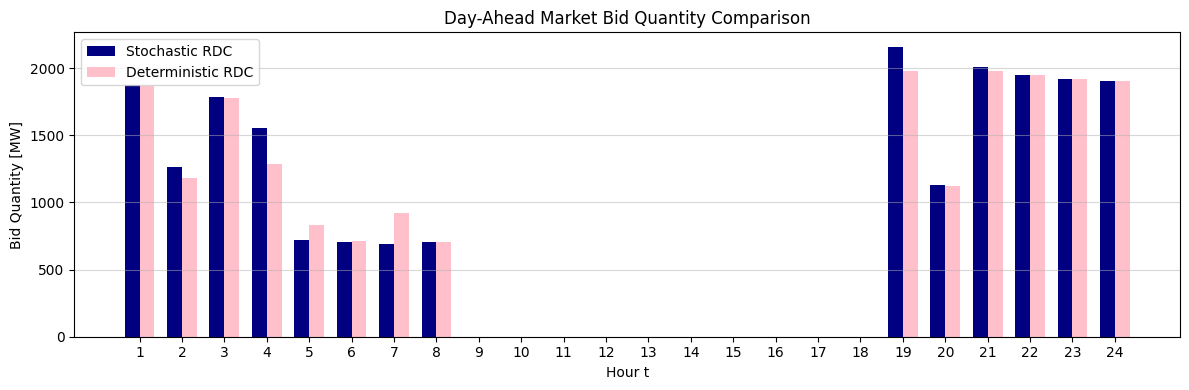

In [13]:
# ---------- p_bid 값 추출 ----------
# ---------- p_bid 값 추출 ----------
# SP (Stochastic RP 해 → Var.X 필요)
p_bid_SP = [p_bid[t].X for t in T]

# EV (Deterministic EV 해 → 이미 float 값이므로 .X 필요 없음)
p_bid_EV = [ev_sol["p_bid"][t] for t in T]
# ---------- 시각화 ----------
x = np.arange(len(T))  # 시간 축 (0~23)
width = 0.35           # 막대 폭

plt.figure(figsize=(12,4))
plt.bar(x - width/2, p_bid_SP, width, label="Stochastic RDC", color="navy")
plt.bar(x + width/2, p_bid_EV, width, label="Deterministic RDC", color="pink")

plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Day-Ahead Market Bid Quantity Comparison")
plt.xticks(x, T)   # x축 라벨을 Hour index로 표시
plt.legend()
plt.grid(True, axis="y", alpha=0.5)
plt.tight_layout()
plt.show()
